Created a dummy 'sleep_data.csv' file. Please replace it with your actual data for meaningful results.
Dataset Preview:
   Sleep_Duration  Awakenings  ADHD
0        4.581754           0     0
1        8.816924           1     0
2        7.262932           1     1
3        5.920576           4     0
4        4.779924           2     0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sleep_Duration  100 non-null    float64
 1   Awakenings      100 non-null    int64  
 2   ADHD            100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB
None

Features used for prediction:
Index(['Sleep_Duration', 'Awakenings'], dtype='object')

Training samples: 80
Testing samples: 20

Model Accuracy: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.58    

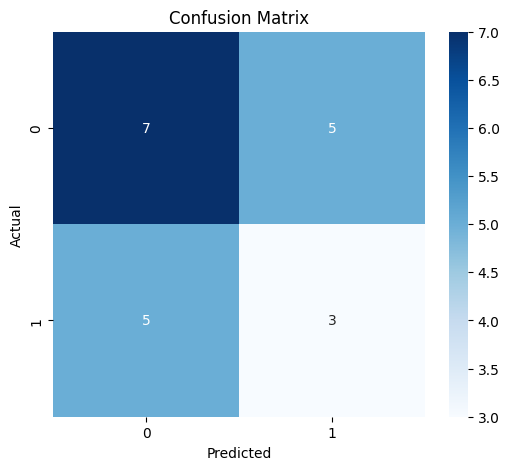

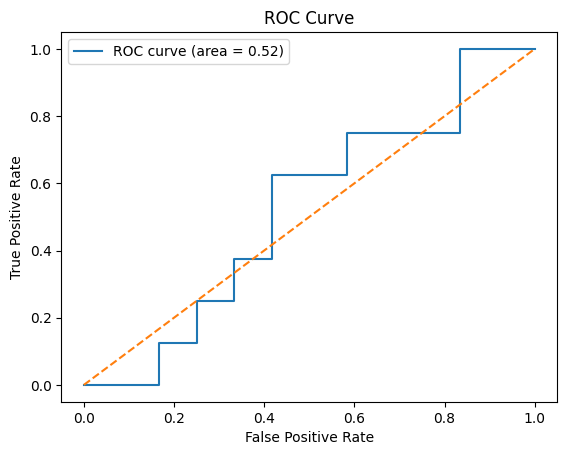


Feature Importance:
          Feature  Importance
0  Sleep_Duration    0.817849
1      Awakenings    0.182151


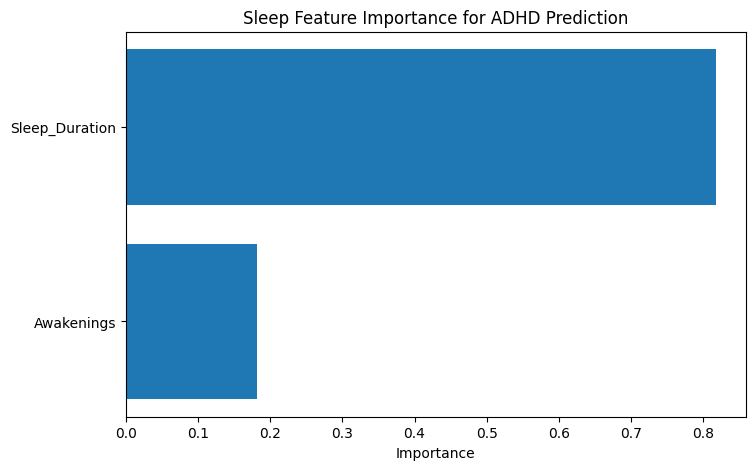


Model saved as sleep_adhd_model.pkl


In [4]:
# ---------------------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
# ---------------------------------------------------------
# 2. LOAD DATASET
# ---------------------------------------------------------

# Create a dummy sleep_data.csv for demonstration if the file is not found
import os
if not os.path.exists("sleep_data.csv"):
    dummy_data = {
        'Sleep_Duration': np.random.uniform(4, 10, 100),
        'Awakenings': np.random.randint(0, 5, 100),
        'ADHD': np.random.randint(0, 2, 100) # 0 or 1 for ADHD presence
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv("sleep_data.csv", index=False)
    print("Created a dummy 'sleep_data.csv' file. Please replace it with your actual data for meaningful results.")

# Example dataset file
df = pd.read_csv("sleep_data.csv")

print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ---------------------------------------------------------
# 3. DATA CLEANING
# ---------------------------------------------------------

# Remove missing values
df = df.dropna()
# ---------------------------------------------------------
# 4. FEATURE SELECTION
# ---------------------------------------------------------

# Target column
target = "ADHD"

# Features
X = df.drop(target, axis=1)
y = df[target]

print("\nFeatures used for prediction:")
print(X.columns)

# ---------------------------------------------------------
# 5. DATA NORMALIZATION
# ---------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
# ---------------------------------------------------------
# 6. TRAIN TEST SPLIT
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
    )
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
# ---------------------------------------------------------
# 7. TRAIN MACHINE LEARNING MODEL
# ---------------------------------------------------------
model = RandomForestClassifier(
                    n_estimators=300,
                    max_depth=10,
                    random_state=42
                    )
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 8. MAKE PREDICTIONS
# ---------------------------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------------------------
# 9. MODEL EVALUATION
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# ---------------------------------------------------------
# 10. CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ---------------------------------------------------------
# 11. ROC CURVE
# ---------------------------------------------------------

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()
# ---------------------------------------------------------
# 12. FEATURE IMPORTANCE
# ---------------------------------------------------------

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance

plt.figure(figsize=(8,5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Sleep Feature Importance for ADHD Prediction")

plt.gca().invert_yaxis()

plt.show()

# ---------------------------------------------------------
# 13. SAVE TRAINED MODEL
# ---------------------------------------------------------

import joblib

joblib.dump(model, "sleep_adhd_model.pkl")

print("\nModel saved as sleep_adhd_model.pkl")